In [1]:
import pandas as pd

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [59]:
age = np.random.randint(18,65,200)
discount = np.random.randint(0,40,200)
z = (age * 0.1) + (discount * 0.2) - 6
probabilities = 1 / (1 + np.exp(-z))
bought = (probabilities > 0.5).astype(int)
df = pd.DataFrame({
    'Age': age,
    'Discount': discount,
    'Sales': bought
})
df.head()

,Age,Discount,Sales
0,36,39,1
1,24,18,0
2,52,37,1
3,44,24,1
4,41,31,1


In [60]:
X = df[['Age','Discount']] 
y = df['Sales']


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape,X_test.shape)

(160, 2) (40, 2)


In [69]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("Data readed succesfully")

Data readed succesfully


In [70]:
predict = model.predict(X_test)
predict

array([0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1])

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [71]:
correct_answer = accuracy_score(y_test, predict)
print(correct_answer * 100 , "%")

100.0 %


In [72]:
cm = confusion_matrix(y_test, predict)
print(cm)

[[ 9  0]
 [ 0 31]]


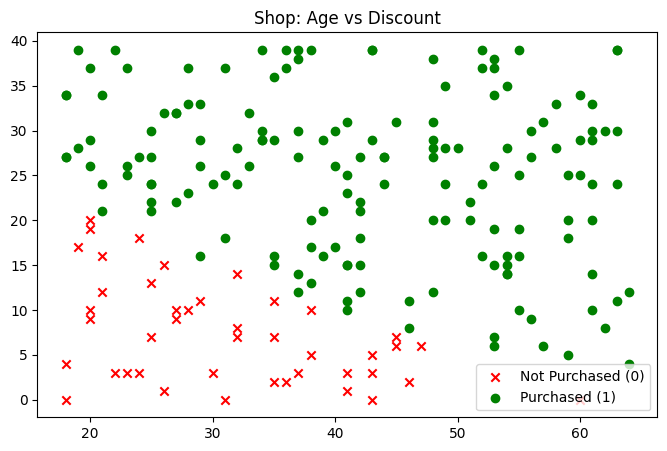

In [75]:

plt.figure(figsize=(8, 5))

nahi_kharida = df[df['Sales'] == 0]
plt.scatter(nahi_kharida['Age'], nahi_kharida['Discount'], color='red', marker='x', label='Not Purchased (0)')

kharida = df[df['Sales'] == 1]
plt.scatter(kharida['Age'], kharida['Discount'], color='green', marker='o', label='Purchased (1)')

plt.title('Shop: Age vs Discount')
plt.legend()
plt.show()

In [57]:
import seaborn as sns

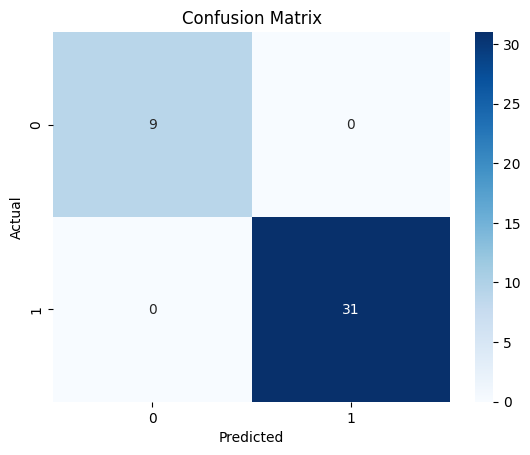

In [74]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()